In [ ]:
# pyenv activate nitrates

In [24]:
import pandas as pd
from utils import *
import matplotlib.pyplot as plt

## Registro Ramblas Mar Menor

In [2]:
filename = "Registro_Ramblas_MARMENOR.xlsx"

In [10]:
# Cargamos las hojas que nos interesan del xlsx

df_caudal = pd.read_excel(filename, sheet_name="Caudal", skiprows=6, usecols=range(1,26)).dropna(how="all")
df_nitratos = pd.read_excel(filename, sheet_name="Nitratos", skiprows=6, usecols=range(1,25)).dropna(how="all")
df_fosfatos = pd.read_excel(filename, sheet_name="Fosfatos", skiprows=6, usecols=range(1,25)).dropna(how="all")
df_conductividad = pd.read_excel(filename, sheet_name="Conductividad", skiprows=6, usecols=range(1,25)).dropna(how="all")
df_nitratosdiario = pd.read_excel(filename, sheet_name="NitratosDiario", skiprows=6, usecols=range(1,14)).dropna(how="all")
df_fosfatosdiario = pd.read_excel(filename, sheet_name="FosfatosDiario", skiprows=6, usecols=range(1,14)).dropna(how="all")

# Lista de DataFrames
dataframes = [df_caudal, df_nitratos, df_fosfatos, df_conductividad, df_nitratosdiario, df_fosfatosdiario]

In [67]:
for i in range(len(dataframes)):
    # Extraemos la fecha más reciente en las instancias que tienen dos fechas
    dataframes[i]['Fecha'] = dataframes[i]['Fecha'].apply(extract_recent_date)
    # Quitamos las entradas que no tienen fecha
    dataframes[i] = dataframes[i][~dataframes[i]['Fecha'].isna()]
    # Ponemos como 0's todas las observaciones que no tienen un valor
    dataframes[i] = dataframes[i].fillna(0)
    # Ponemos como 0's todas los strings
    dataframes[i] = dataframes[i].applymap(replace_strings)


# Definir el umbral
threshold = 0.95
# Función para encontrar columnas con más del 95% de ceros en un DataFrame
def columns_with_high_zero_percentage(df, threshold):
    zero_percentage = (df == 0).mean()
    return set(zero_percentage[zero_percentage > threshold].index)
# Encontrar columnas con más del 90% de ceros en cada DataFrame
columns_sets = [columns_with_high_zero_percentage(df, threshold) for df in [df_caudal, df_nitratos, df_fosfatos, df_conductividad]] # La suma diaria de nitratos y fosfatos no se considera porque tiene menos columnas
# Encontrar la intersección de estas columnas en todos los DataFrames
common_columns = set.intersection(*columns_sets)

for i in range(len(dataframes)):
    dataframes[i].drop(columns=common_columns, inplace=True, errors="ignore")

# Reasignar los DataFrames procesados a sus variables originales
df_caudal, df_nitratos, df_fosfatos, df_conductividad, df_nitratosdiario, df_fosfatosdiario = dataframes


In [68]:
df_caudal

,Fecha,Total desaguado por rambla Albujón,Drenaje Los Alcázares,Desembocadura rambla Albujón,Tuberías salmuera bajo N-332,Canal D-7,Azud CHS,Tramo Medio Rambla Albujón,Surgencia,Aliviadero,Obra de paso bajo carretera Los Urrutia,Desembocadura rambla de Miranda,Desembocadura rambla del Miedo,Desembocadura rambla de las Matildes,Rambla de las Matildes - corriente sur,Lo Poyo,Lengua de Vaca,Freático Los Alcázares,Venta Simón
1,2019-08-30,0.00,0.92,0.00,0,47.41,0.0,0.00,0,0.0,0.0,0.0,0,0.00,0.00,0.00,0.0,0.00,0.00
2,2019-09-06,0.00,0.83,0.00,0,0.00,0.0,0.00,0,0.0,0.0,0.0,0,0.00,0.00,0.00,0.0,0.00,0.00
3,2019-09-20,0.00,0.00,0.00,0,0.00,0.0,0.00,0,0.0,0.0,0.0,0,0.00,0.00,0.00,0.0,0.00,0.00
4,2019-09-26,0.00,0.00,0.00,0,227.90,0.0,0.00,0,0.0,0.0,0.0,0,0.00,0.00,0.00,0.0,0.00,0.00
5,2019-10-02,0.00,0.00,0.00,0,217.71,0.0,29.01,0,0.0,0.0,0.0,0,0.00,0.00,0.00,0.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,2024-03-13,121.56,0.00,121.56,0,45.97,0.0,0.00,0,0.0,0.0,0.0,0,0.00,2.12,2.56,0.0,1.60,0.00
464,2024-03-15,131.48,0.00,131.48,0,36.85,0.0,0.00,0,0.0,0.0,0.0,0,0.00,2.26,2.18,0.0,0.00,0.00
465,2024-03-20,131.48,0.00,127.24,0,32.57,0.0,0.00,0,0.0,0.0,0.0,0,0.00,2.52,2.20,0.0,3.08,0.00
466,2024-03-22,131.48,0.00,138.49,0,30.98,0.0,0.00,0,0.0,0.0,0.0,0,0.00,2.24,3.00,0.0,3.99,0.00


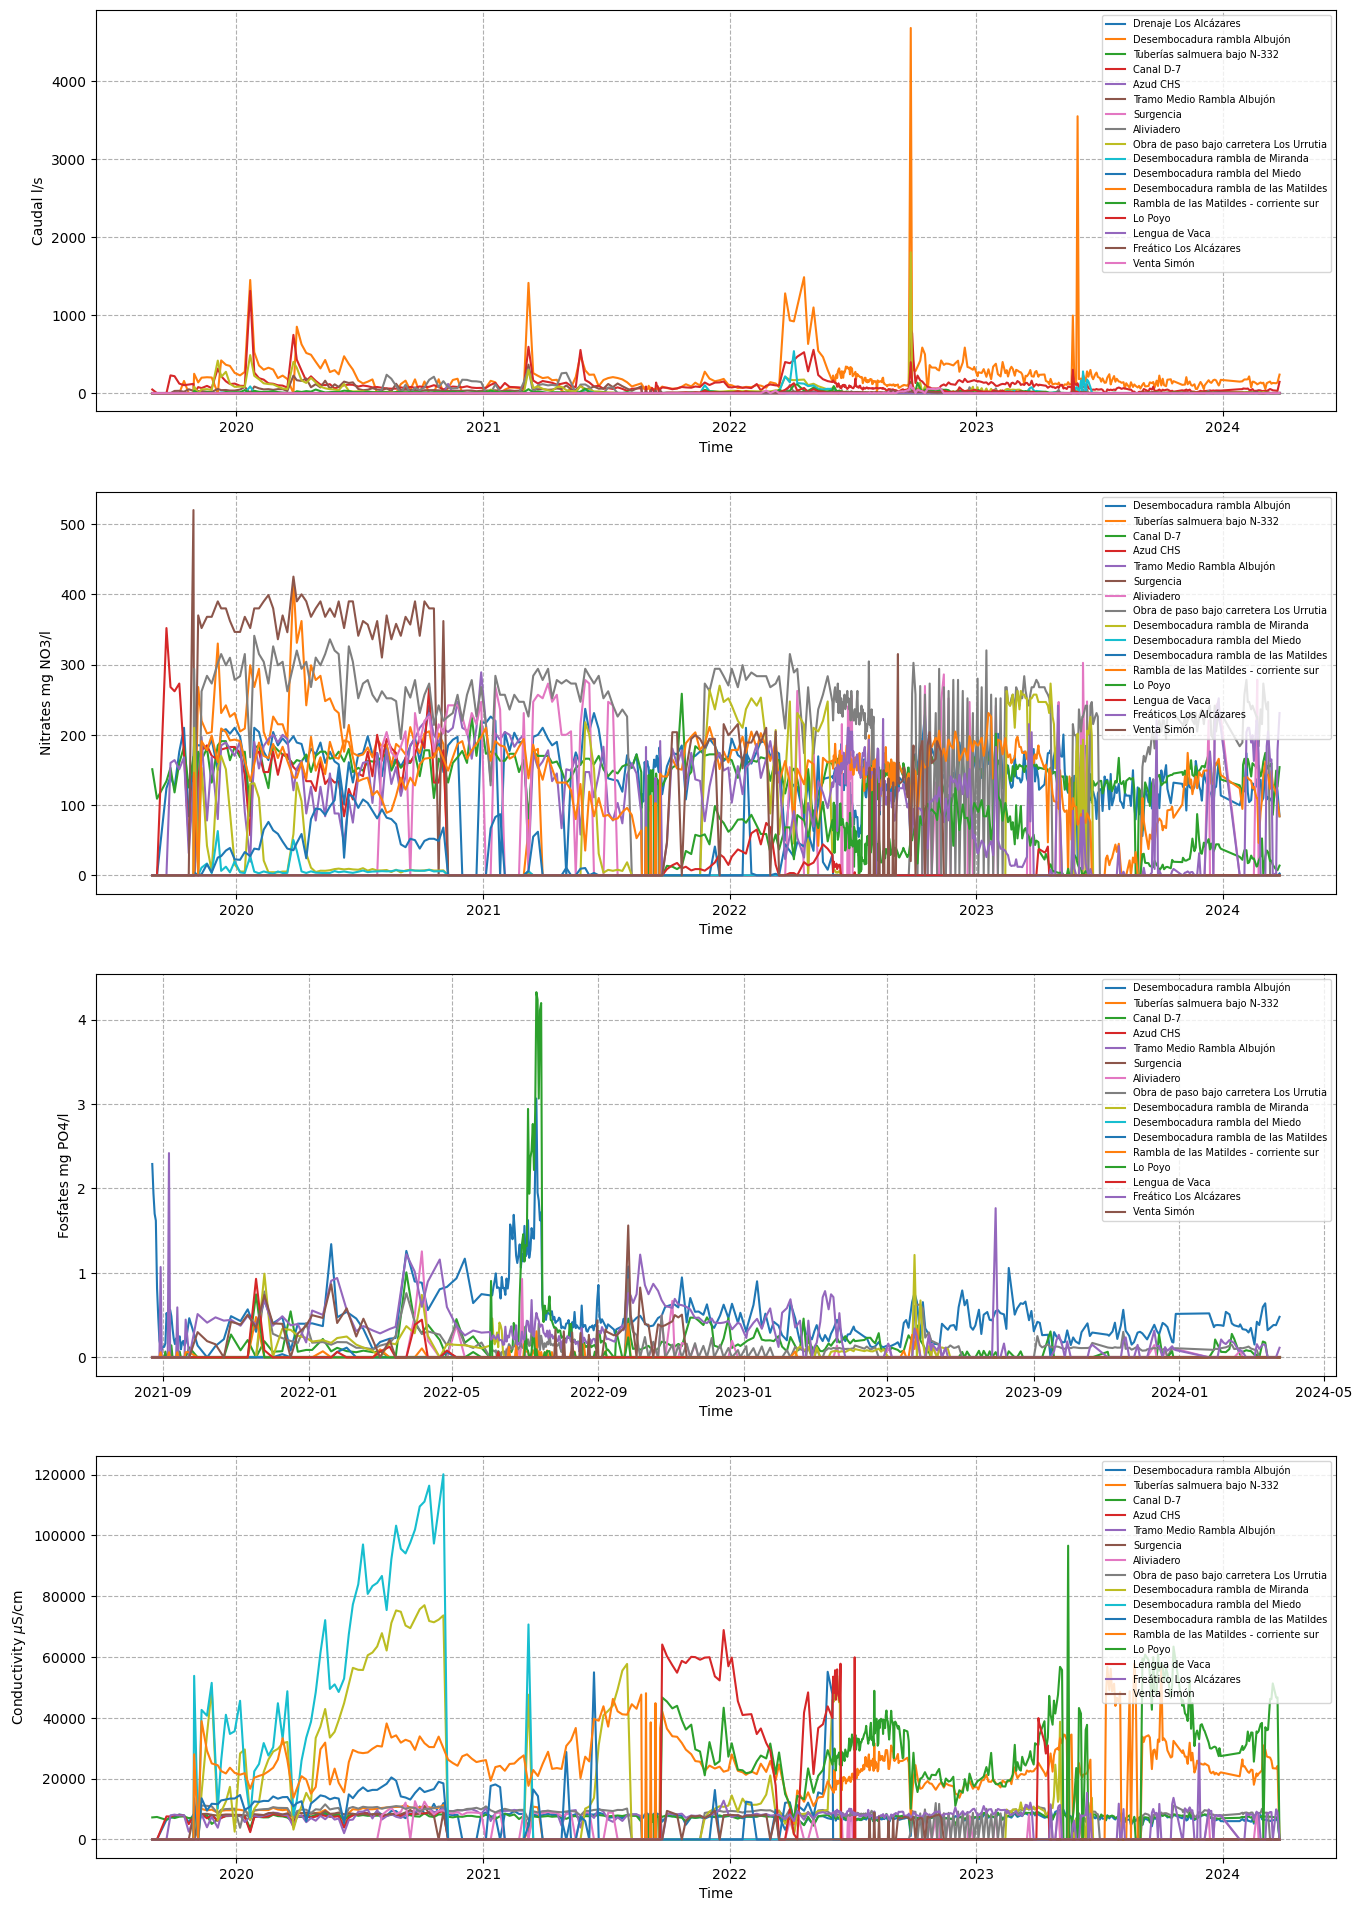

In [85]:
fig, ax = plt.subplots(figsize = (16,24), nrows=4, ncols=1)
for col in df_caudal.columns[2:]:
    ax[0].plot(df_caudal["Fecha"], df_caudal[col], label = f"{col}")
ax[0].legend(loc="upper right", fontsize = 7)
ax[0].set_ylabel("Caudal l/s")
ax[0].set_xlabel("Time")
ax[0].grid(linestyle = '--')

for col in df_nitratos.columns[2:]:
    ax[1].plot(df_nitratos["Fecha"], df_nitratos[col], label = f"{col}")
ax[1].legend(loc="upper right", fontsize = 7)
ax[1].set_ylabel("Nitrates mg NO3/l")
ax[1].set_xlabel("Time")
ax[1].grid(linestyle = '--')

for col in df_fosfatos.columns[2:]:
    ax[2].plot(df_fosfatos["Fecha"], df_fosfatos[col], label = f"{col}")
ax[2].legend(loc="upper right", fontsize = 7)
ax[2].set_ylabel("Fosfates mg PO4/l")
ax[2].set_xlabel("Time")
ax[2].grid(linestyle = '--')

for col in df_conductividad.columns[2:]:
    ax[3].plot(df_conductividad["Fecha"], df_conductividad[col], label = f"{col}")
ax[3].legend(loc="upper right", fontsize = 7)
ax[3].set_ylabel("Conductivity $\mu$S/cm")
ax[3].set_xlabel("Time")
ax[3].grid(linestyle = '--')

## Boyas UPCT

In [ ]:
path = "boyaUPCT/extractedData/"

In [ ]:
# Agrupar por localización o por variables??